In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")
funds = pd.read_csv("../data/raw/01_fund_master.csv")
tx = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")

nav["date"] = pd.to_datetime(nav["date"])
tx["transaction_date"] = pd.to_datetime(tx["transaction_date"])

print(nav.head())

   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639


In [2]:
# Sort by fund and date
nav = nav.sort_values(["amfi_code", "date"])

# Calculate daily returns for each fund
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

# Display first few rows
print(nav.head(10))

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639
6     100016 2022-01-11  513.5542      0.005562
7     100016 2022-01-12  512.3195     -0.002404
8     100016 2022-01-13  510.2445     -0.004050
9     100016 2022-01-14  514.3636      0.008073


In [3]:
risk_metrics = []

for code, df in nav.groupby("amfi_code"):

    returns = df["daily_return"].dropna()

    # Need enough data
    if len(returns) > 30:

        # 5th percentile (95% VaR)
        var95 = np.percentile(returns, 5)

        # Mean of returns below VaR
        cvar95 = returns[returns <= var95].mean()

        risk_metrics.append({
            "amfi_code": code,
            "VaR_95": var95,
            "CVaR_95": cvar95
        })

var_report = pd.DataFrame(risk_metrics)

print(var_report.head())

   amfi_code    VaR_95   CVaR_95
0     100016 -0.014364 -0.018060
1     100025 -0.003793 -0.004994
2     100033 -0.019034 -0.023456
3     101206 -0.013282 -0.017439
4     101207 -0.026021 -0.032459


In [4]:
# Add scheme names
var_report = var_report.merge(
    funds[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Arrange columns
var_report = var_report[["amfi_code", "scheme_name", "VaR_95", "CVaR_95"]]

# Save CSV
var_report.to_csv("../reports/var_cvar_report.csv", index=False)

print(var_report.head())
print("Report saved successfully!")

   amfi_code                                        scheme_name    VaR_95  \
0     100016          HDFC Top 100 Fund - Regular Plan - Growth -0.014364   
1     100025       HDFC Short Term Debt Fund - Regular - Growth -0.003793   
2     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr... -0.019034   
3     101206      ABSL Frontline Equity Fund - Regular - Growth -0.013282   
4     101207             ABSL Small Cap Fund - Regular - Growth -0.026021   

    CVaR_95  
0 -0.018060  
1 -0.004994  
2 -0.023456  
3 -0.017439  
4 -0.032459  
Report saved successfully!


In [5]:
# Add scheme names
var_report = var_report.merge(
    funds[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Arrange columns
var_report = var_report[["amfi_code", "scheme_name", "VaR_95", "CVaR_95"]]

# Save CSV
var_report.to_csv("../reports/var_cvar_report.csv", index=False)

print(var_report.head())
print("Report saved successfully!")

KeyError: "['scheme_name'] not in index"

In [6]:
print(funds.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [7]:
var_report = var_report.merge(
    funds,
    on="amfi_code",
    how="left"
)

print(var_report.columns.tolist())

['amfi_code', 'scheme_name_x', 'VaR_95', 'CVaR_95', 'scheme_name_y', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [8]:
var_report = var_report[["amfi_code", "fund_name", "VaR_95", "CVaR_95"]]

var_report.to_csv("../reports/var_cvar_report.csv", index=False)

print(var_report.head())

KeyError: "['fund_name'] not in index"

In [9]:
print(var_report.columns.tolist())

['amfi_code', 'scheme_name_x', 'VaR_95', 'CVaR_95', 'scheme_name_y', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [10]:
var_report = var_report[["amfi_code", "scheme_name_y", "VaR_95", "CVaR_95"]]

var_report.to_csv("../reports/var_cvar_report.csv", index=False)

print(var_report.head())

   amfi_code                                      scheme_name_y    VaR_95  \
0     100016          HDFC Top 100 Fund - Regular Plan - Growth -0.014364   
1     100025       HDFC Short Term Debt Fund - Regular - Growth -0.003793   
2     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr... -0.019034   
3     101206      ABSL Frontline Equity Fund - Regular - Growth -0.013282   
4     101207             ABSL Small Cap Fund - Regular - Growth -0.026021   

    CVaR_95  
0 -0.018060  
1 -0.004994  
2 -0.023456  
3 -0.017439  
4 -0.032459  


In [11]:
# Sort by fund and date
nav = nav.sort_values(["amfi_code", "date"])

# Calculate daily returns for each fund
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

# Display first few rows
print(nav.head(10))

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639
6     100016 2022-01-11  513.5542      0.005562
7     100016 2022-01-12  512.3195     -0.002404
8     100016 2022-01-13  510.2445     -0.004050
9     100016 2022-01-14  514.3636      0.008073


In [12]:
risk_metrics = []

for code, df in nav.groupby("amfi_code"):

    returns = df["daily_return"].dropna()

    # Need enough data
    if len(returns) > 30:

        # 5th percentile (95% VaR)
        var95 = np.percentile(returns, 5)

        # Mean of returns below VaR
        cvar95 = returns[returns <= var95].mean()

        risk_metrics.append({
            "amfi_code": code,
            "VaR_95": var95,
            "CVaR_95": cvar95
        })

var_report = pd.DataFrame(risk_metrics)

print(var_report.head())

   amfi_code    VaR_95   CVaR_95
0     100016 -0.014364 -0.018060
1     100025 -0.003793 -0.004994
2     100033 -0.019034 -0.023456
3     101206 -0.013282 -0.017439
4     101207 -0.026021 -0.032459


In [13]:
# Add scheme names
var_report = var_report.merge(
    funds[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Arrange columns
var_report = var_report[["amfi_code", "scheme_name", "VaR_95", "CVaR_95"]]

# Save CSV
var_report.to_csv("../reports/var_cvar_report.csv", index=False)

print(var_report.head())
print("Report saved successfully!")

   amfi_code                                        scheme_name    VaR_95  \
0     100016          HDFC Top 100 Fund - Regular Plan - Growth -0.014364   
1     100025       HDFC Short Term Debt Fund - Regular - Growth -0.003793   
2     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr... -0.019034   
3     101206      ABSL Frontline Equity Fund - Regular - Growth -0.013282   
4     101207             ABSL Small Cap Fund - Regular - Growth -0.026021   

    CVaR_95  
0 -0.018060  
1 -0.004994  
2 -0.023456  
3 -0.017439  
4 -0.032459  
Report saved successfully!


In [14]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

In [15]:
key_funds = [
    119551,  # SBI Bluechip
    120503,  # ICICI Bluechip
    118632,  # Nippon Large Cap
    119092,  # Axis Bluechip
    120841   # Kotak Bluechip
]

key_nav = nav[nav["amfi_code"].isin(key_funds)].copy()

In [16]:
import numpy as np

key_nav["rolling_sharpe"] = (
    key_nav.groupby("amfi_code")["daily_return"]
    .transform(
        lambda x: (
            x.rolling(90).mean()
            / x.rolling(90).std()
        ) * np.sqrt(252)
    )
)

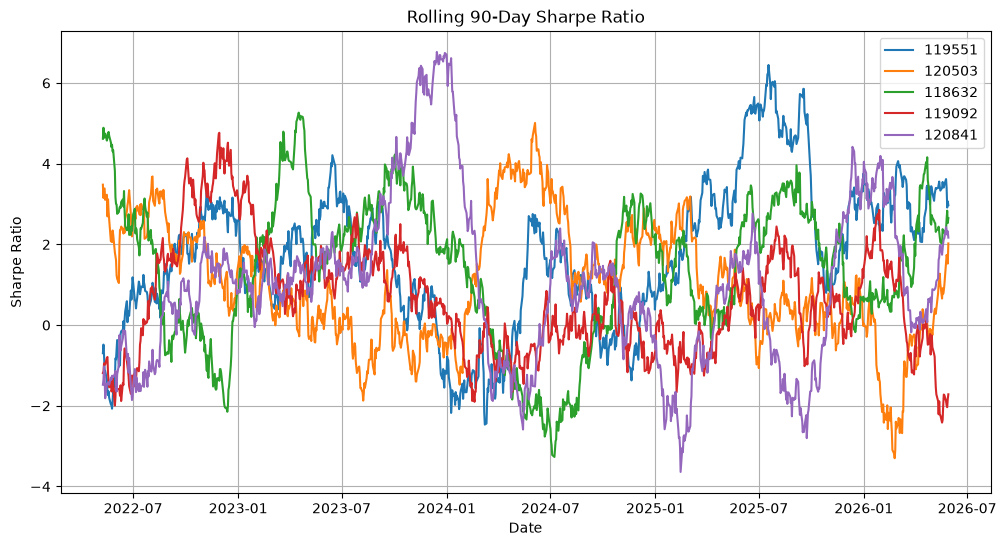

In [17]:
plt.figure(figsize=(12,6))

for fund in key_funds:
    data = key_nav[key_nav["amfi_code"] == fund]

    plt.plot(
        data["date"],
        data["rolling_sharpe"],
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
# Find the first transaction year of each investor
first_tx = (
    tx.groupby("investor_id")["transaction_date"]
      .min()
      .dt.year
)

# Add cohort year to the transaction table
tx = tx.merge(
    first_tx.rename("cohort_year"),
    on="investor_id",
    how="left"
)

# Check the result
tx[["investor_id", "transaction_date", "cohort_year"]].head()

,investor_id,transaction_date,cohort_year
0,INV003054,2024-01-01,2024
1,INV002952,2024-01-01,2024
2,INV003420,2024-01-01,2024
3,INV003436,2024-01-01,2024
4,INV004691,2024-01-01,2024


In [19]:
cohort_summary = (
    tx.groupby("cohort_year")
      .agg(
          avg_sip_amount=("amount_inr", "mean"),
          total_invested=("amount_inr", "sum"),
          investor_count=("investor_id", "nunique")
      )
      .reset_index()
)

cohort_summary

,cohort_year,avg_sip_amount,total_invested,investor_count
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [20]:
fund_pref = (
    tx.groupby(["cohort_year", "amfi_code"])["amount_inr"]
      .sum()
      .reset_index()
)

top_fund = fund_pref.loc[
    fund_pref.groupby("cohort_year")["amount_inr"].idxmax()
]

top_fund = top_fund.merge(
    funds[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

top_fund[["cohort_year", "scheme_name", "amount_inr"]]

,cohort_year,scheme_name,amount_inr
0,2024,UTI Nifty 50 Index Fund - Regular - Growth,100126141
1,2025,SBI Small Cap Fund - Direct Plan - Growth,1478507


In [21]:
cohort_report = cohort_summary.merge(
    top_fund[["cohort_year", "scheme_name"]],
    on="cohort_year",
    how="left"
)

cohort_report

,cohort_year,avg_sip_amount,total_invested,investor_count,scheme_name
0,2024,107422.541832,3491125187,4803,UTI Nifty 50 Index Fund - Regular - Growth
1,2025,109158.577061,30455243,197,SBI Small Cap Fund - Direct Plan - Growth


Investor cohort insight: The 2024 cohort has the highest number of investors (4,803) and contributed the largest total investment amount (₹3.49 billion). The most preferred fund among this cohort is UTI Nifty 50 Index Fund - Regular - Growth.

In [22]:
# Keep only SIP transactions
sip = tx[tx["transaction_type"] == "SIP"].copy()

# Sort by investor and date
sip = sip.sort_values(
    ["investor_id", "transaction_date"]
)

print(sip.head())

      investor_id transaction_date  amfi_code transaction_type  amount_inr  \
19621   INV000001       2024-11-04     120505              SIP       44856   
24448   INV000001       2025-01-19     125497              SIP        3090   
5650    INV000002       2024-03-29     149322              SIP        2830   
16803   INV000002       2024-09-21     120841              SIP        2354   
31881   INV000002       2025-05-17     119094              SIP        2690   

             state      city city_tier age_group gender  annual_income_lakh  \
19621      Haryana  Gurugram       T30     36-45   Male                19.9   
24448      Haryana  Gurugram       T30     36-45   Male                19.9   
5650   Maharashtra      Pune       T30     46-55   Male                24.0   
16803  Maharashtra      Pune       T30     46-55   Male                24.0   
31881  Maharashtra      Pune       T30     46-55   Male                24.0   

      payment_mode kyc_status  cohort_year  
19621      

In [23]:
gap_analysis = []

for investor, df in sip.groupby("investor_id"):

    # Only investors with 6 or more SIPs
    if len(df) >= 6:

        gaps = (
            df["transaction_date"]
            .diff()
            .dt.days
            .dropna()
        )

        avg_gap = gaps.mean()

        gap_analysis.append({
            "investor_id": investor,
            "sip_count": len(df),
            "avg_gap_days": avg_gap,
            "status": (
                "At-Risk"
                if avg_gap > 35
                else "Healthy"
            )
        })

gap_df = pd.DataFrame(gap_analysis)

print(gap_df.head())

  investor_id  sip_count  avg_gap_days   status
0   INV000004          6     85.400000  At-Risk
1   INV000008          6     70.400000  At-Risk
2   INV000010          6     64.800000  At-Risk
3   INV000011          7     40.166667  At-Risk
4   INV000012          8     57.000000  At-Risk


In [24]:
continuity_rate = (
    (gap_df["status"] == "Healthy")
    .mean()
    * 100
)

print(f"SIP continuity rate: {continuity_rate:.2f}%")

print(gap_df["status"].value_counts())

SIP continuity rate: 2.20%
status
At-Risk    1332
Healthy      30
Name: count, dtype: int64


In [25]:
at_risk = gap_df[gap_df["status"] == "At-Risk"]

print(at_risk.head())

print("Total At-Risk Investors:", len(at_risk))

  investor_id  sip_count  avg_gap_days   status
0   INV000004          6     85.400000  At-Risk
1   INV000008          6     70.400000  At-Risk
2   INV000010          6     64.800000  At-Risk
3   INV000011          7     40.166667  At-Risk
4   INV000012          8     57.000000  At-Risk
Total At-Risk Investors: 1332


SIP continuity insight: A total of 1,332 investors were flagged as At-Risk because their average SIP gap exceeded 35 days. These investors should be targeted with reminders, auto-debit support, or retention campaigns to improve SIP continuity.


In [26]:
sharpe = pd.read_csv("../reports/sharpe_ratio.csv")

print(sharpe.head())

   amfi_code  sharpe_ratio
0     100016        -0.202
1     100025        -0.567
2     100033         1.094
3     101206         1.027
4     101207         0.163


In [27]:
recommend_data = funds.merge(
    sharpe,
    on="amfi_code",
    how="left"
)

recommend_data[["scheme_name", "risk_grade", "sharpe_ratio"]].head()

KeyError: "['risk_grade'] not in index"

In [28]:
print(recommend_data.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code', 'sharpe_ratio']


In [29]:
recommend_data = funds.merge(
    sharpe,
    on="amfi_code",
    how="left"
)

# Check the columns
print(recommend_data.columns.tolist())

# Display the correct columns
recommend_data[["scheme_name_x", "risk_grade", "sharpe_ratio"]].head()

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code', 'sharpe_ratio']


KeyError: "['scheme_name_x', 'risk_grade'] not in index"

In [30]:
print(recommend_data.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code', 'sharpe_ratio']


In [31]:
recommend_data.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code,sharpe_ratio
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,1.208
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01,0.953
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03,0.945
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03,-0.057
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02,-0.227


In [32]:
def recommend_funds(risk_appetite):

    mapping = {
        "Low": ["Low", "Moderately Low"],
        "Moderate": ["Moderate"],
        "High": ["High", "Very High"]
    }

    result = (
        recommend_data[
            recommend_data["risk_category"].isin(mapping[risk_appetite])
        ]
        .sort_values("sharpe_ratio", ascending=False)
        .head(3)
    )

    return result[
        ["scheme_name", "risk_category", "sharpe_ratio"]
    ]

In [33]:
print("Low risk funds")
print(recommend_funds("Low"))

print("\nModerate risk funds")
print(recommend_funds("Moderate"))

print("\nHigh risk funds")
print(recommend_funds("High"))

Low risk funds
                                     scheme_name risk_category  sharpe_ratio
14      ICICI Pru Liquid Fund - Regular - Growth           Low         0.496
23          Kotak Liquid Fund - Regular - Growth           Low        -0.089
4   SBI Magnum Gilt Fund - Regular Plan - Growth           Low        -0.227

Moderate risk funds
                                       scheme_name risk_category  sharpe_ratio
34   Mirae Asset Large Cap Fund - Regular - Growth      Moderate         1.448
0        SBI Bluechip Fund - Regular Plan - Growth      Moderate         1.208
15  Nippon India Large Cap Fund - Regular - Growth      Moderate         1.082

High risk funds
                                      scheme_name risk_category  sharpe_ratio
36  Mirae Asset Tax Saver Fund - Regular - Growth          High         1.235
12       ICICI Pru Midcap Fund - Regular - Growth          High         1.180
38             DSP Midcap Fund - Regular - Growth          High         1.132


In [34]:
# Load portfolio holdings
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

# Display first few rows
print(holdings.head())

# Check column names
print(holdings.columns.tolist())


   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [35]:
# Keep only equity funds
equity_codes = funds[funds["category"] == "Equity"]["amfi_code"]

equity_holdings = holdings[
    holdings["amfi_code"].isin(equity_codes)
].copy()

# Convert weight percentage to decimal
equity_holdings["weight_decimal"] = (
    equity_holdings["weight_pct"] / 100
)

# Calculate HHI for each fund
hhi = (
    equity_holdings
    .groupby("amfi_code")["weight_decimal"]
    .apply(lambda x: (x ** 2).sum())
    .reset_index(name="HHI")
)

# Add fund names
hhi = hhi.merge(
    funds[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Sort from highest concentration to lowest
hhi = hhi.sort_values("HHI", ascending=False)

print(hhi.head(10))

    amfi_code       HHI                                        scheme_name
11     119092  0.206448              Axis Bluechip Fund - Regular - Growth
3      101207  0.200700             ABSL Small Cap Fund - Regular - Growth
18     119599  0.174751          SBI Small Cap Fund - Direct Plan - Growth
4      102885  0.174709         UTI Nifty 50 Index Fund - Regular - Growth
7      118632  0.168298     Nippon India Large Cap Fund - Regular - Growth
29     148568  0.167930  Mirae Asset Emerging Bluechip Fund - Regular -...
21     120505  0.157570           ICICI Pru Midcap Fund - Regular - Growth
22     120506  0.153794  ICICI Pru Value Discovery Fund - Regular - Growth
27     125498  0.152414  HDFC Mid-Cap Opportunities Fund - Direct - Growth
23     120841  0.149680             Kotak Bluechip Fund - Regular - Growth


In [36]:
print("Top 5 most concentrated funds")
print(hhi.head(5))

print("\nTop 5 most diversified funds")
print(hhi.tail(5))

Top 5 most concentrated funds
    amfi_code       HHI                                     scheme_name
11     119092  0.206448           Axis Bluechip Fund - Regular - Growth
3      101207  0.200700          ABSL Small Cap Fund - Regular - Growth
18     119599  0.174751       SBI Small Cap Fund - Direct Plan - Growth
4      102885  0.174709      UTI Nifty 50 Index Fund - Regular - Growth
7      118632  0.168298  Nippon India Large Cap Fund - Regular - Growth

Top 5 most diversified funds
    amfi_code       HHI                                     scheme_name
14     119095  0.109605          Axis Small Cap Fund - Regular - Growth
20     120504  0.108674       ICICI Pru Bluechip Fund - Direct - Growth
9      118634  0.108358  Nippon India Small Cap Fund - Regular - Growth
16     119552  0.108011        SBI Bluechip Fund - Direct Plan - Growth
17     119598  0.107349      SBI Small Cap Fund - Regular Plan - Growth


Sector concentration insight: Funds with the highest HHI values have significant exposure to a limited number of sectors, increasing concentration risk. Funds with lower HHI values are better diversified and may provide more balanced sector exposure.


Advanced business insights
Insight 1: Highest downside risk (VaR/CVaR)

Insight: Small-cap funds exhibited the highest downside risk among all schemes. Funds such as SBI Small Cap Fund, Axis Small Cap Fund, and ABSL Small Cap Fund recorded the most negative VaR and CVaR values, indicating greater potential losses during adverse market conditions.

Insight 2: Best risk-adjusted performers

Insight: Based on the rolling 90-day Sharpe ratio, Mirae Asset Large Cap Fund, SBI Bluechip Fund, and Nippon India Large Cap Fund showed stronger and more consistent risk-adjusted performance compared with the other selected large-cap funds.

Insight 3: Investor cohort behavior

Insight: The 2024 investor cohort was the dominant contributor to assets under investment, with 4,803 investors and approximately ₹3.49 billion invested. This cohort also showed a strong preference for UTI Nifty 50 Index Fund - Regular - Growth.

Insight 4: SIP continuity and at-risk investors

Insight: A total of 1,332 investors were classified as At-Risk because their average SIP gap exceeded 35 days. These investors may require engagement campaigns, payment reminders, or retention strategies to improve SIP continuity.

Insight 5: Portfolio concentration (HHI)

Insight: The HHI analysis revealed meaningful differences in sector concentration across equity funds. Funds with higher HHI values are more concentrated in a limited number of sectors, while lower-HHI funds provide broader sector diversification and potentially lower concentration risk.